PHAN 4: TRAINING - HUAN LUYEN MO HINH

1. DOC DU LIEU DA XU LY
--------------------------------------------------
X_train: (6056, 19)
X_val:   (757, 19)
X_test:  (758, 19)
So dac trung: 19

Thong ke nhan:
   Train - Normal: 3,373, Attack: 2,683 (44.30%)
   Val   - Normal: 422, Attack: 335 (44.25%)
   Test  - Normal: 422, Attack: 336 (44.33%)

2. TINH CLASS WEIGHT (BALANCED)
Class weights:
   - class 0 (Normal): 0.8977
   - class 1 (Attack): 1.1286
   -> scale_pos_weight cho XGBoost: 1.2572

3. DINH NGHIA CAC MO HINH (8 MO HINH)
So luong mo hinh: 8
   - Logistic Regression
   - Naive Bayes
   - Decision Tree
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - KNN
   - SVM

4. HUAN LUYEN VA SO SANH CAC MO HINH

KET QUA DANH GIA TREN VALIDATION SET:
----------------------------------------------------------------------------------------------------
Model                  Train Acc    Val Acc      Val F1       Val AUC      Val Recall  
----------------------------------------------

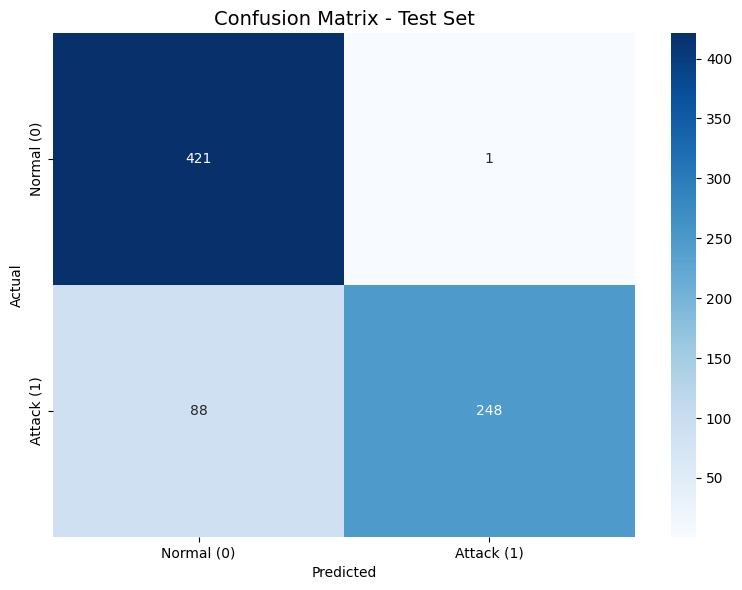


Da luu confusion_matrix.png

9. FEATURE IMPORTANCE

TOP 20 DAC TRUNG QUAN TRONG NHAT:
------------------------------------------------------------
    4. failed_logins                                      -> 0.2780 (27.80%)
    2. login_attempts                                     -> 0.2408 (24.08%)
    3. ip_reputation_score                                -> 0.2265 (22.65%)
    1. network_packet_size                                -> 0.0485 (4.85%)
    7. session_duration_log                               -> 0.0460 (4.60%)
    8. packet_density_log                                 -> 0.0434 (4.34%)
   15. browser_type_Unknown                               -> 0.0392 (3.92%)
    6. ip_risk_score                                      -> 0.0356 (3.56%)
    5. login_failure_ratio                                -> 0.0154 (1.54%)
   11. encryption_used_DES                                -> 0.0058 (0.58%)
   19. unusual_time_access                                -> 0.0045 (0.45%)
   13. browse

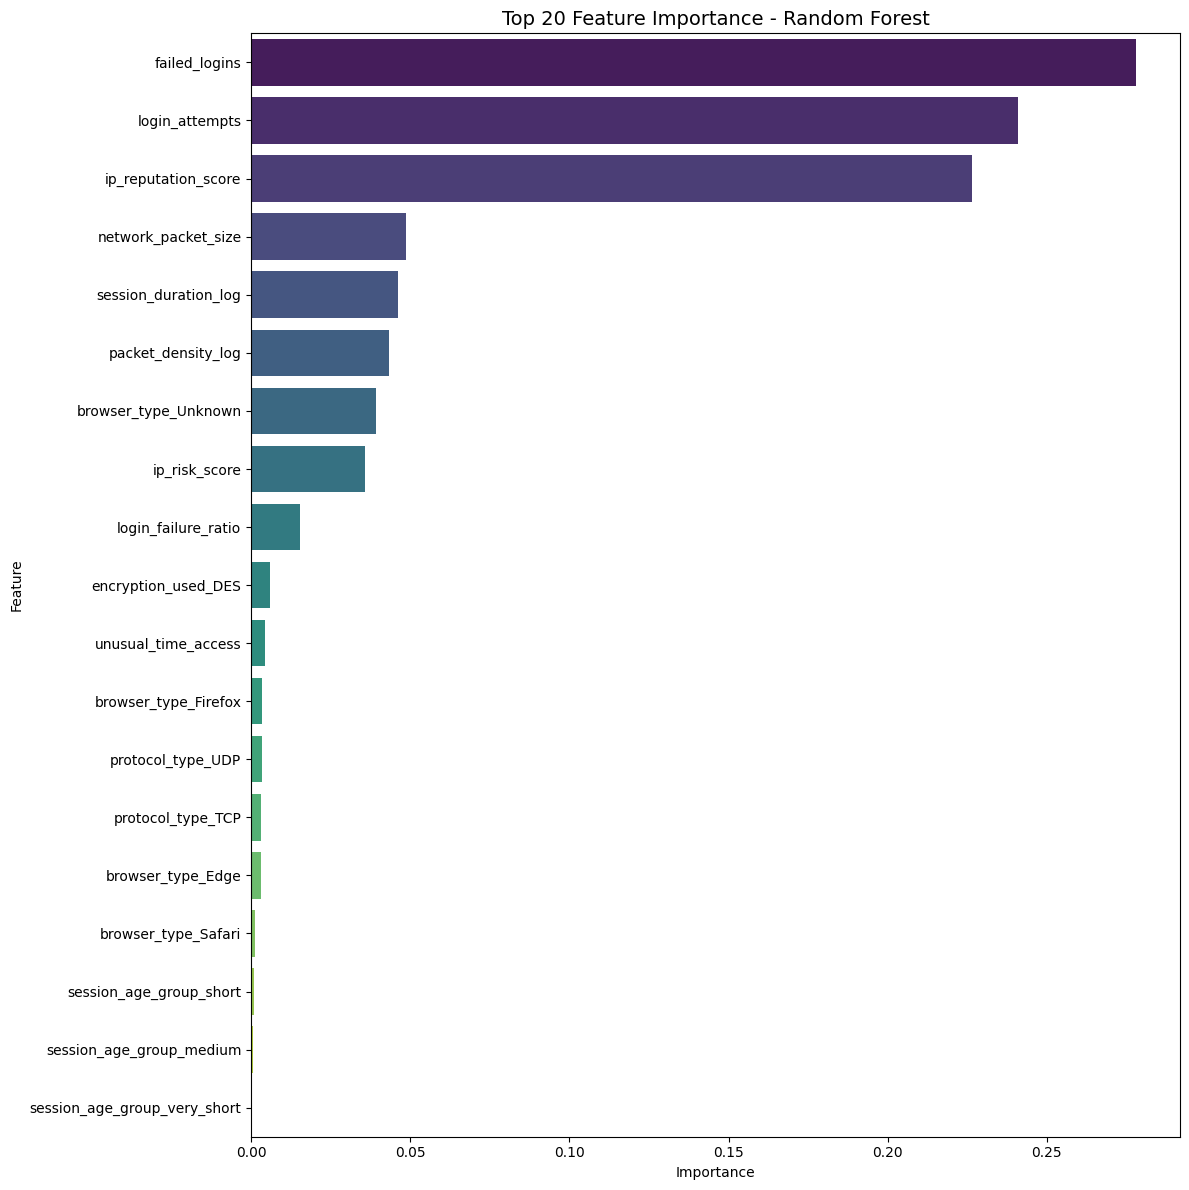


10. LUU MO HINH
Da luu mo hinh cuoi cung vao: ../models/final_model.pkl
Da luu ket qua training vao: ../models/training_results.csv

11. TOM TAT KET QUA

TOM TAT HUAN LUYEN MO HINH

1. DU LIEU:
   - Train: 6,056 mau
   - Validation: 757 mau
   - Test: 758 mau
   - So dac trung: 19
   - Ty le tan cong (test): 44.33%

2. KET QUA CAC MO HINH (TREN VALIDATION):

   - Random Forest          -> F1: 0.8744 | AUC: 0.8931
   - Gradient Boosting      -> F1: 0.8721 | AUC: 0.8833
   - Decision Tree          -> F1: 0.8709 | AUC: 0.8918
   - XGBoost                -> F1: 0.8675 | AUC: 0.8943
   - SVM                    -> F1: 0.8430 | AUC: 0.8718
   - KNN                    -> F1: 0.7858 | AUC: 0.8565
   - Naive Bayes            -> F1: 0.7718 | AUC: 0.8432
   - Logistic Regression    -> F1: 0.6771 | AUC: 0.7947

3. MO HINH TOT NHAT SAU TOI UU:
   - Mo hinh: Random Forest (Tuned)
   - F1-Score tren TEST: 0.8479 (84.79%)
   - ROC-AUC tren TEST:  0.8679 (86.79%)

4. MA TRAN NHAM LAN (TREN TEST):
   - 

In [ ]:

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)
from sklearn.utils.class_weight import compute_class_weight

print("="*80)
print("PHAN 4: TRAINING - HUAN LUYEN MO HINH")
print("="*80)

# =============================================================================
# 1. DOC DU LIEU DA XU LY
# =============================================================================

print("\n1. DOC DU LIEU DA XU LY")
print("-"*50)

X_train = joblib.load("../data_processed/X_train_processed.pkl")
y_train = joblib.load("../data_processed/y_train.pkl")
X_val = joblib.load("../data_processed/X_val_processed.pkl")
y_val = joblib.load("../data_processed/y_val.pkl")
X_test = joblib.load("../data_processed/X_test_processed.pkl")
y_test = joblib.load("../data_processed/y_test.pkl")
feature_names = joblib.load("../models/feature_names.pkl")

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"So dac trung: {len(feature_names)}")

print(f"\nThong ke nhan:")
print(f"   Train - Normal: {(y_train == 0).sum():,}, Attack: {(y_train == 1).sum():,} ({y_train.mean():.2%})")
print(f"   Val   - Normal: {(y_val == 0).sum():,}, Attack: {(y_val == 1).sum():,} ({y_val.mean():.2%})")
print(f"   Test  - Normal: {(y_test == 0).sum():,}, Attack: {(y_test == 1).sum():,} ({y_test.mean():.2%})")

# =============================================================================
# 2. TINH CLASS WEIGHT
# =============================================================================

print("\n" + "="*80)
print("2. TINH CLASS WEIGHT (BALANCED)")
print("="*80)

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print(f"Class weights:")
print(f"   - class 0 (Normal): {class_weight_dict[0]:.4f}")
print(f"   - class 1 (Attack): {class_weight_dict[1]:.4f}")
print(f"   -> scale_pos_weight cho XGBoost: {class_weight_dict[1]/class_weight_dict[0]:.4f}")

# =============================================================================
# 3. DINH NGHIA CAC MO HINH
# =============================================================================

print("\n" + "="*80)
print("3. DINH NGHIA CAC MO HINH (8 MO HINH)")
print("="*80)

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000, class_weight=class_weight_dict
    ),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, max_depth=10, class_weight=class_weight_dict
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, n_estimators=100, n_jobs=-1, class_weight=class_weight_dict
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42, n_estimators=100
    ),
    'XGBoost': XGBClassifier(
        random_state=42, n_estimators=100, use_label_encoder=False, 
        eval_metric='logloss', scale_pos_weight=class_weight_dict[1]/class_weight_dict[0]
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=42, probability=True, class_weight=class_weight_dict)
}

print(f"So luong mo hinh: {len(models)}")
for name in models.keys():
    print(f"   - {name}")

# =============================================================================
# 4. HUAN LUYEN VA SO SANH CAC MO HINH
# =============================================================================

print("\n" + "="*80)
print("4. HUAN LUYEN VA SO SANH CAC MO HINH")
print("="*80)

results = []
best_model = None
best_val_f1 = 0
best_model_name = ""

print("\nKET QUA DANH GIA TREN VALIDATION SET:")
print("-"*100)
print(f"{'Model':<22} {'Train Acc':<12} {'Val Acc':<12} {'Val F1':<12} {'Val AUC':<12} {'Val Recall':<12}")
print("-"*100)

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    
    if hasattr(model, 'predict_proba'):
        y_val_proba = model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, y_val_proba)
    else:
        val_auc = np.nan
    
    print(f"{name:<22} {train_acc:<12.4f} {val_acc:<12.4f} {val_f1:<12.4f} {val_auc:<12.4f} {val_recall:<12.4f}")
    
    results.append({
        'Model': name,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Val_F1': val_f1,
        'Val_AUC': val_auc,
        'Val_Recall': val_recall
    })
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model = model
        best_model_name = name

print("-"*100)

best_recall = None
for r in results:
    if r['Model'] == best_model_name:
        best_recall = r['Val_Recall']
        break

print(f"\nMO HINH TOT NHAT TREN VALIDATION: {best_model_name}")
print(f"   - F1-Score: {best_val_f1:.4f}")
if best_recall is not None:
    print(f"   - Recall:   {best_recall:.4f}")

# =============================================================================
# 5. TOI UU SIEU THAM SO CHO RANDOM FOREST
# =============================================================================

print("\n" + "="*80)
print("5. TOI UU SIEU THAM SO CHO RANDOM FOREST")
print("="*80)

print("\nDang tim kiem sieu tham so toi uu cho Random Forest...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_base = RandomForestClassifier(
    random_state=42, n_jobs=-1, class_weight=class_weight_dict
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nSieu tham so toi uu tim duoc:")
for param, value in grid_search.best_params_.items():
    print(f"   -> {param}: {value}")
print(f"\nDiem F1 tot nhat (cross-validation): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

y_val_pred_rf = best_rf.predict(X_val)
y_val_proba_rf = best_rf.predict_proba(X_val)[:, 1]
val_f1_rf = f1_score(y_val, y_val_pred_rf)
val_auc_rf = roc_auc_score(y_val, y_val_proba_rf)
val_recall_rf = recall_score(y_val, y_val_pred_rf)

print(f"\nKET QUA SAU TUNING (tren validation):")
print(f"   -> F1-Score: {val_f1_rf:.4f}")
print(f"   -> ROC-AUC:  {val_auc_rf:.4f}")
print(f"   -> Recall:   {val_recall_rf:.4f}")

# =============================================================================
# 6. ENSEMBLE LEARNING (VOTING CLASSIFIER)
# =============================================================================

print("\n" + "="*80)
print("6. ENSEMBLE LEARNING - VOTING CLASSIFIER")
print("="*80)

top_3_results = sorted(results, key=lambda x: x['Val_F1'], reverse=True)[:3]
print(f"\nTop {len(top_3_results)} mo hinh duoc chon de ensemble:")
for m in top_3_results:
    print(f"   - {m['Model']}: F1 = {m['Val_F1']:.4f}")

estimators = []
for m in top_3_results:
    model_name = m['Model']
    if model_name in models:
        if model_name == 'Random Forest':
            model = best_rf
        else:
            model = models[model_name]
            model.fit(X_train, y_train)
        estimators.append((model_name.lower().replace(' ', '_'), model))

voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft'
)

voting_clf.fit(X_train, y_train)

y_val_pred_voting = voting_clf.predict(X_val)
y_val_proba_voting = voting_clf.predict_proba(X_val)[:, 1]
val_f1_voting = f1_score(y_val, y_val_pred_voting)
val_auc_voting = roc_auc_score(y_val, y_val_proba_voting)

print(f"\nKET QUA VOTING CLASSIFIER (tren validation):")
print(f"   -> F1-Score: {val_f1_voting:.4f}")
print(f"   -> ROC-AUC:  {val_auc_voting:.4f}")

if val_f1_voting > val_f1_rf:
    print(f"\nVoting Classifier tot hon Random Forest (+{val_f1_voting - val_f1_rf:.4f} F1)")
    final_model = voting_clf
    final_model_name = "Voting Classifier"
else:
    print(f"\nRandom Forest van tot hon Voting Classifier")
    final_model = best_rf
    final_model_name = "Random Forest (Tuned)"

# =============================================================================
# 7. DANH GIA CUOI CUNG TREN TAP TEST
# =============================================================================

print("\n" + "="*80)
print("7. DANH GIA CUOI CUNG TREN TAP TEST")
print("="*80)

y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nKET QUA TREN TAP TEST (CHUA NHIN THAY BAO GIO):")
print("-"*60)
print(f"   Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Precision: {test_prec:.4f} ({test_prec*100:.2f}%)")
print(f"   Recall:    {test_rec:.4f} ({test_rec*100:.2f}%)")
print(f"   F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   ROC-AUC:   {test_auc:.4f} ({test_auc*100:.2f}%)")

compare_val = val_f1_rf if final_model_name == "Random Forest (Tuned)" else val_f1_voting
print(f"\nSO SANH VALIDATION VS TEST:")
print(f"   - Validation F1: {compare_val:.4f}")
print(f"   - Test F1:       {test_f1:.4f}")
print(f"   - Chenh lech:    {abs(compare_val - test_f1):.4f}")

if abs(compare_val - test_f1) > 0.05:
    print("   CANH BAO: Co dau hieu overfitting hoac phan phoi du lieu khong dong nhat!")
else:
    print("   Ket qua on dinh, khong co dau hieu ro ri du lieu.")

# =============================================================================
# 8. CONFUSION MATRIX
# =============================================================================

print("\n" + "="*80)
print("8. CONFUSION MATRIX TREN TAP TEST")
print("="*80)

cm = confusion_matrix(y_test, y_test_pred)
print(f"\n   True Negative  (TN): {cm[0,0]:,}")
print(f"   False Positive (FP): {cm[0,1]:,}")
print(f"   False Negative (FN): {cm[1,0]:,}")
print(f"   True Positive  (TP): {cm[1,1]:,}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'])
plt.title(f'Confusion Matrix - Test Set', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()

print("\nDa luu confusion_matrix.png")

# =============================================================================
# 9. FEATURE IMPORTANCE
# =============================================================================

if final_model_name == "Random Forest (Tuned)" or isinstance(final_model, RandomForestClassifier):
    print("\n" + "="*80)
    print("9. FEATURE IMPORTANCE")
    print("="*80)
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTOP 20 DAC TRUNG QUAN TRONG NHAT:")
    print("-"*60)
    for i, row in importance_df.head(20).iterrows():
        print(f"   {i+1:2d}. {row['Feature']:<50} -> {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")
    
    plt.figure(figsize=(12, 12))
    top_features = importance_df.head(20)
    sns.barplot(data=top_features, y='Feature', x='Importance', palette='viridis')
    plt.title('Top 20 Feature Importance - Random Forest', fontsize=14)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig('../models/feature_importance.png', dpi=150)
    plt.show()
else:
    print("\nKhong the hien thi feature importance vi mo hinh cuoi cung khong phai Random Forest")

# =============================================================================
# 10. LUU MO HINH
# =============================================================================

print("\n" + "="*80)
print("10. LUU MO HINH")
print("="*80)

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/final_model.pkl")
print("Da luu mo hinh cuoi cung vao: ../models/final_model.pkl")

results_df = pd.DataFrame(results)
results_df.to_csv("../models/training_results.csv", index=False)
print("Da luu ket qua training vao: ../models/training_results.csv")

# =============================================================================
# 11. TOM TAT
# =============================================================================

print("\n" + "="*80)
print("11. TOM TAT KET QUA")
print("="*80)

print(f"""
TOM TAT HUAN LUYEN MO HINH
========================================

1. DU LIEU:
   - Train: {X_train.shape[0]:,} mau
   - Validation: {X_val.shape[0]:,} mau
   - Test: {X_test.shape[0]:,} mau
   - So dac trung: {len(feature_names)}
   - Ty le tan cong (test): {y_test.mean():.2%}

2. KET QUA CAC MO HINH (TREN VALIDATION):
""")
for r in sorted(results, key=lambda x: x['Val_F1'], reverse=True):
    print(f"   - {r['Model']:<22} -> F1: {r['Val_F1']:.4f} | AUC: {r['Val_AUC']:.4f}")

print(f"""
3. MO HINH TOT NHAT SAU TOI UU:
   - Mo hinh: {final_model_name}
   - F1-Score tren TEST: {test_f1:.4f} ({test_f1*100:.2f}%)
   - ROC-AUC tren TEST:  {test_auc:.4f} ({test_auc*100:.2f}%)

4. MA TRAN NHAM LAN (TREN TEST):
   - True Negative  (TN): {cm[0,0]:,}
   - False Positive (FP): {cm[0,1]:,}
   - False Negative (FN): {cm[1,0]:,}
   - True Positive  (TP): {cm[1,1]:,}

5. KET LUAN:
   - Mo hinh dat F1-Score = {test_f1:.4f} ({test_f1*100:.2f}%)
   - Mo hinh dat ROC-AUC = {test_auc:.4f} ({test_auc*100:.2f}%)
""")

print("\nHOAN THANH TRAINING")
print("="*80)